In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

abs_phenotypes = False

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'enhancer_encode'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml" 

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: enhancer_encode
  Filters: ["(pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)", "pl.col('pangolin_score') < 0.2", "pl.col('encode_enhancer') == True"]
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [3]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

# olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000116675""","""ENSG00000116675_olink""",0.022487,0.022487,1.0
"""ENSG00000123609""","""ENSG00000123609_olink""",0.076186,0.076186,1.0
"""ENSG00000167851""","""ENSG00000167851_olink""",0.066067,0.066067,1.0
"""ENSG00000156711""","""ENSG00000156711_olink""",0.04852,0.04852,1.0
"""ENSG00000174990""","""ENSG00000174990_olink""",0.010786,0.010786,1.0
…,…,…,…,…
"""ENSG00000136542""","""ENSG00000136542_olink""",0.040315,0.040315,1.0
"""ENSG00000196576""","""ENSG00000196576_olink""",0.082542,0.082542,1.0
"""ENSG00000111144""","""ENSG00000111144_olink""",0.088107,0.088107,1.0


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = pl.scan_parquet(new_anno_local)
# rna_cols = [c for c in new_anno_df.collect_schema().names() if c.startswith('RNA:')]
# 89 GTEx tissue tracks:
gtex_cols = ['RNA:adipose_tissue_7522', 'RNA:adipose_tissue_7523', 'RNA:adipose_tissue_7524', 'RNA:adrenal_gland_7525', 'RNA:adrenal_gland_7526', 'RNA:adrenal_gland_7527', 'RNA:bladder_7528', 'RNA:bladder_7529', 'RNA:bladder_7530', 'RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533', 'RNA:blood_vessel_7534', 'RNA:blood_vessel_7535', 'RNA:blood_vessel_7536', 'RNA:bone_marrow_7537', 'RNA:bone_marrow_7538', 'RNA:brain_7539', 'RNA:brain_7540', 'RNA:brain_7541', 'RNA:breast_7542', 'RNA:breast_7543', 'RNA:breast_7544', 'RNA:cervix_uteri_7545', 'RNA:cervix_uteri_7546', 'RNA:cervix_uteri_7547', 'RNA:colon_7548', 'RNA:colon_7549', 'RNA:colon_7550', 'RNA:esophagus_7551', 'RNA:esophagus_7552', 'RNA:esophagus_7553', 'RNA:fallopian_tube_7554', 'RNA:fallopian_tube_7555', 'RNA:fallopian_tube_7556', 'RNA:heart_7557', 'RNA:heart_7558', 'RNA:heart_7559', 'RNA:kidney_7560', 'RNA:kidney_7561', 'RNA:kidney_7562', 'RNA:liver_7563', 'RNA:liver_7564', 'RNA:liver_7565', 'RNA:lung_7566', 'RNA:lung_7567', 'RNA:lung_7568', 'RNA:muscle_7569', 'RNA:muscle_7570', 'RNA:muscle_7571', 'RNA:nerve_7572', 'RNA:nerve_7573', 'RNA:ovary_7574', 'RNA:ovary_7575', 'RNA:ovary_7576', 'RNA:pancreas_7577', 'RNA:pancreas_7578', 'RNA:pancreas_7579', 'RNA:pituitary_7580', 'RNA:pituitary_7581', 'RNA:pituitary_7582', 'RNA:prostate_7583', 'RNA:prostate_7584', 'RNA:prostate_7585', 'RNA:salivary_gland_7586', 'RNA:salivary_gland_7587', 'RNA:salivary_gland_7588', 'RNA:skin_7589', 'RNA:skin_7590', 'RNA:skin_7591', 'RNA:small_intestine_7592', 'RNA:small_intestine_7593', 'RNA:small_intestine_7594', 'RNA:spleen_7595', 'RNA:spleen_7596', 'RNA:spleen_7597', 'RNA:stomach_7598', 'RNA:stomach_7599', 'RNA:stomach_7600', 'RNA:testis_7601', 'RNA:testis_7602', 'RNA:thyroid_7603', 'RNA:thyroid_7604', 'RNA:thyroid_7605', 'RNA:uterus_7606', 'RNA:uterus_7607', 'RNA:vagina_7608', 'RNA:vagina_7609', 'RNA:vagina_7610']

new_anno_df = (
    new_anno_df
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_gtex_min = pl.min_horizontal(gtex_cols),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_gtex_min'] + gtex_cols)
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_all_260218_0_ukbbgym.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_242915/2268322955.py:20: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_gtex_min,RNA:adipose_tissue_7522,RNA:adipose_tissue_7523,RNA:adipose_tissue_7524,RNA:adrenal_gland_7525,RNA:adrenal_gland_7526,RNA:adrenal_gland_7527,RNA:bladder_7528,RNA:bladder_7529,RNA:bladder_7530,RNA:blood_7531,RNA:blood_7532,RNA:blood_7533,RNA:blood_vessel_7534,RNA:blood_vessel_7535,RNA:blood_vessel_7536,RNA:bone_marrow_7537,RNA:bone_marrow_7538,RNA:brain_7539,RNA:brain_7540,RNA:brain_7541,RNA:breast_7542,RNA:breast_7543,RNA:breast_7544,RNA:cervix_uteri_7545,RNA:cervix_uteri_7546,RNA:cervix_uteri_7547,RNA:colon_7548,RNA:colon_7549,RNA:colon_7550,RNA:esophagus_7551,RNA:esophagus_7552,RNA:esophagus_7553,RNA:fallopian_tube_7554,…,RNA:ovary_7574,RNA:ovary_7575,RNA:ovary_7576,RNA:pancreas_7577,RNA:pancreas_7578,RNA:pancreas_7579,RNA:pituitary_7580,RNA:pituitary_7581,RNA:pituitary_7582,RNA:prostate_7583,RNA:prostate_7584,RNA:prostate_7585,RNA:salivary_gland_7586,RNA:salivary_gland_7587,RNA:salivary_gland_7588,RNA:skin_7589,RNA:skin_7590,RNA:skin_7591,RNA:small_intestine_7592,RNA:small_intestine_7593,RNA:small_intestine_7594,RNA:spleen_7595,RNA:spleen_7596,RNA:spleen_7597,RNA:stomach_7598,RNA:stomach_7599,RNA:stomach_7600,RNA:testis_7601,RNA:testis_7602,RNA:thyroid_7603,RNA:thyroid_7604,RNA:thyroid_7605,RNA:uterus_7606,RNA:uterus_7607,RNA:vagina_7608,RNA:vagina_7609,RNA:vagina_7610
str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.006898,-0.004409,-0.003202,-0.003796,-0.002167,-0.000225,0.000029,0.000096,-0.000163,-0.00029,-0.000072,-0.000313,-0.001006,-0.000016,-0.000103,-0.000966,-0.004409,-0.000849,-0.000766,-0.000102,-0.000357,-0.000407,-0.000644,0.000054,-0.003439,0.000052,0.000076,-0.000193,-0.000062,-0.000394,-0.000245,-0.00001,-0.000043,-0.000115,9.5367e-7,…,0.000223,0.000224,-0.000028,0.000374,0.000317,0.000299,-0.000082,-0.000075,-0.000067,0.000061,-0.000255,-0.000003,-0.00004,-0.000033,-0.000291,0.000043,-0.000159,-0.00013,-0.00028,-0.000264,-0.000092,-0.000044,-0.000152,0.000025,-0.000034,-0.000202,-0.000137,-0.000054,-0.000227,-0.000002,0.000003,-0.000026,0.000031,0.00001,-0.00014,0.000033,-0.000201
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.013746,-0.013746,0.000104,0.000019,0.000456,-0.000479,-0.000024,0.000005,0.000533,-0.000933,0.000546,-0.00056,-0.000939,-0.000166,0.001661,0.001739,0.001287,-0.002052,-0.001732,-0.000978,-0.000298,-0.000368,-0.001042,-0.001266,-0.000277,0.001163,-0.000495,-0.0005,0.000937,-0.001903,-0.000072,0.000477,0.000697,-0.001071,0.000628,…,0.00175,0.00178,0.000958,-0.002445,-0.002463,-0.002056,-0.000767,-0.001166,-0.001192,-0.001463,0.000623,-0.001124,-0.001858,-0.001914,-0.001042,-0.000064,0.011024,-0.000551,-0.012403,-0.007233,0.000114,-0.000785,-0.000742,-0.000525,0.000649,-0.001888,-0.001628,-0.000269,-0.000416,-0.000876,-0.000722,-0.001254,0.001175,0.000854,-0.000123,0.000206,0.000941
"""chr12:10309195:A:G""","""ENSG00000134539""",-0.01001,-0.003757,0.018677,0.015531,0.017328,0.009183,0.013514,0.012793,0.012763,0.01293,0.01951,0.019411,0.002706,0.002081,0.02533,0.023569,0.02132,0.001112,-0.000299,0.012206,0.01115,0.01197,0.015909,0.013903,0.014265,0.014954,0.011189,0.026192,0.019374,0.007202,0.009556,0.020193,0.018116,0.024347,0.015241,…,0.018805,0.015975,0.015615,0.007869,0.006789,0.005348,0.005113,0.007125,0.005134,0.009871,0.015984,0.010708,0.009926,0.011983,0.027232,0.029582,0.054492,0.024977,0.00361,0.003041,0.010993,0.000532,-0.001254,0.001731,0.018975,0.00707,0.008204,-0.002058,-0.003757,0.01214,0.012171,0.011278,0.021222,0.018786,0.025299,0.023925,0.019372
"""chr2:162198524:G:A""","""ENSG00000078098""",-0.002404,0.003302,0.0058,0.003801,0.003526,0.006878,0.007512,0.00641,0.004052,0.005671,0.004462,0.00508,0.007588,0.006954,0.004242,0.003742,0.004097,0.00

In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
_dynamic_filters = [eval(f) for f in vc_filters]
if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
    )
)

selected_categories = ['regulatory'] # regulatory

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)).union(set(gtex_cols)))

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_242915/1833671776.py:53: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_242915/1833671776.py:61: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


RNA:adrenal_gland_7526,RNA:testis_7602,RNA:adipose_tissue_7524,RNA:blood_7531,RNA:stomach_7598,RNA:muscle_7571,RNA:fallopian_tube_7556,RNA:uterus_7606,RNA:pancreas_7579,RNA:pituitary_7580,RNA:thyroid_7604,RNA:brain_7540,promoterai_under,RNA:skin_7591,RNA:skin_7590,RNA:muscle_7569,RNA:esophagus_7551,RNA:brain_7539,fz_all_min,RNA:breast_7543,RNA:spleen_7595,RNA:esophagus_7553,RNA:blood_vessel_7536,RNA:colon_7549,RNA:vagina_7610,RNA:ovary_7576,RNA:blood_7532,RNA:muscle_7570,RNA:bone_marrow_7538,RNA:spleen_7596,RNA:adipose_tissue_7523,RNA:salivary_gland_7587,RNA:cervix_uteri_7546,RNA:liver_7563,RNA:kidney_7561,RNA:cervix_uteri_7545,RNA:spleen_7597,…,RNA:pancreas_7577,RNA:brain_7541,RNA:adipose_tissue_7522,RNA:prostate_7584,RNA:fallopian_tube_7555,RNA:heart_7559,RNA:lung_7567,RNA:nerve_7573,RNA:breast_7544,RNA:stomach_7599,RNA:liver_7565,RNA:small_intestine_7593,RNA:cervix_uteri_7547,RNA:prostate_7583,RNA:thyroid_7603,RNA:kidney_7560,region,RNA:small_intestine_7594,RNA:esophagus_7552,RNA:vagina_7608,id,RNA:pancreas_7578,RNA:stomach_7600,RNA:blood_7533,RNA:fallopian_tube_7554,fz_gtex_min,RNA:colon_7550,RNA:kidney_7562,RNA:vagina_7609,RNA:lung_7568,RNA:bladder_7528,RNA:ovary_7575,RNA:bone_marrow_7537,RNA:ovary_7574,RNA:heart_7558,RNA:blood_vessel_7535,RNA:skin_7589
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,f32,f32,f32,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
-0.000007,-0.000007,0.000072,0.000176,-0.000031,0.000154,-0.000105,-0.000101,-0.000077,-0.00005,-0.000063,0.00004,0.0,-0.000076,0.000523,0.000123,-0.000051,0.001188,-0.001094,-0.00011,0.000026,0.000041,-0.000047,-0.000034,-0.00007,-0.000068,0.000297,0.000211,0.000232,0.001095,-0.000091,-0.000052,-0.000105,-0.000007,-0.000031,0.00008,0.000425,…,-0.000042,-0.000026,0.000028,-0.00006,-0.000095,0.000062,-0.000072,-0.000163,0.000045,-0.000039,0.000003,0.000018,-0.000007,-0.000035,-0.000067,-0.000019,"""ENSG00000012983""",-0.000094,-0.000039,0.000026,"""chr14:50448187:G:T""",-0.00003,-0.000012,0.000226,0.000027,-0.000163,-0.000098,-0.000032,-0.000085,-0.000097,0.00001,0.000279,0.000083,-0.000076,0.000027,-0.000036,-0.000028
0.000023,0.000279,0.00006,0.000239,0.000031,-0.000101,0.000136,0.000152,0.0,0.000125,0.000275,0.000161,0.0,0.000236,0.000248,-0.000019,0.000019,-0.000164,-0.001147,0.00014,-0.000387,0.000281,0.000139,0.000113,0.00014,0.000014,-0.000896,-0.000141,0.00049,0.000131,0.000102,0.00008,0.000145,-0.000039,0.000149,0.000227,-0.000321,…,-0.000018,0.000077,0.000025,0.00002,0.000156,-0.000041,0.000088,0.000111,0.000223,0.000206,0.000026,0.000105,0.000422,0.000102,0.000114,0.000163,"""ENSG00000129450""",0.000131,0.000078,0.000405,"""chr19:51140962:G:A""",-0.00001,0.000122,-0.000879,0.000264,-0.000896,0.000168,0.000023,0.000327,-0.000363,0.000257,0.000262,0.000437,0.000057,0.000273,0.00001,0.000178
-0.000123,-0.00028,-0.000501,0.00105,-0.000204,-0.000171,-0.000364,-0.000237,-0.001441,-0.000353,-0.000421,-0.000276,0.0,-0.001935,0.000033,-0.000148,-0.000254,-0.000032,-0.003259,-0.00166,0.000353,-0.000754,-0.00017,-0.003259,-0.000256,-0.000177,0.000233,-0.000083,0.000556,0.000043,-0.000294,-0.001751,-0.001035,-0.000237,-0.000443,-0.000422,0.000269,…,-0.000444,-0.000193,-0.000214,-0.000172,-0.000923,-0.00022,-0.000995,-0.000353,-0.001005,-0.002106,-0.000632,-0.001311,-0.000381,-0.001801,-0.000347,-0.001833,"""ENSG00000198087""",-0.001369,-0.000369,-0.002022,"""chr6:47529965:C:T""",-0.000394,-0.002098,0.000125,-0.000557,-0.003259,-0.000417,-0.000399,-0.002218,-0.000308,-0.000751,-0.000695,0.000482,-0.000173,-0.000385,-0.000163,-0.001473
0.002865,0.001127,0.012339,0.001305,0.004126,0.002658,0.003441,0.003142,0.003687,0.001488,0.003106,-0.001077,0.0,0.002808,0.03176,0.002401,0.003397,-0.00569,-0.00569,0.003175,0.002846,0.003369,0.01726,0.003713,0.004989,0.005026,0.000677,0.002556,-0.0014

In [6]:
melted_anno = (
    anno
    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    ).with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr14:50448187:G:T""","""ENSG00000012983""","""RNA:adrenal_gland_7526""",-0.000007
"""chr19:51140962:G:A""","""ENSG00000129450""","""RNA:adrenal_gland_7526""",0.000023
"""chr6:47529965:C:T""","""ENSG00000198087""","""RNA:adrenal_gland_7526""",-0.000123
"""chr4:88006068:T:C""","""ENSG00000118762""","""RNA:adrenal_gland_7526""",0.002865
"""chr21:44907787:C:G""","""ENSG00000160255""","""RNA:adrenal_gland_7526""",0.004087
…,…,…,…
"""chr22:31075683:A:G""","""ENSG00000183963""","""RNA:skin_7589""",-0.001677
"""chr18:54828715:C:A""","""ENSG00000041353""","""RNA:skin_7589""",-0.028264
"""chr2:74374279:T:G""","""ENSG00000204843""","""RNA:skin_7589""",0.053972


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Small APPV file has no 'region' column — region is added via id_region join in the computation cell
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(-pl.col('mean_pheno_value')) # Descending for olink
    )
    .select(['id', 'phenotype', 'mean_pheno_value', 'n_individuals'])
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


---
# Correlation per tissue

In [8]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Join order: appv → id_region (adds region) → olink_whitelist (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(
        olink_whitelist[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(['region', 'phenotype', 'annotation', 'n_variants', 'correlation'])

    .drop_nans().drop_nulls()

    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan

    # .join(
    #     anno_config_df,
    #     on='annotation'
    # )
    .join(
        olink_whitelist,
        on=['region', 'phenotype'],
    )
    .with_columns(
        # corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir')
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*(-1) # under-expression
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

correlation_df

region,phenotype,annotation,n_variants,correlation,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,f64,f64,f64,f64,f64
"""ENSG00000170054""","""ENSG00000170054_olink""","""RNA:pituitary_7581""",342,0.05352,0.031059,0.031059,1.0,-0.05352,-1.723185
"""ENSG00000155368""","""ENSG00000155368_olink""","""RNA:adipose_tissue_7524""",204,-0.03879,0.061938,0.061938,1.0,0.03879,0.626268
"""ENSG00000145384""","""ENSG00000145384_olink""","""RNA:fallopian_tube_7556""",72,-0.07023,0.112064,0.112064,1.0,0.07023,0.626692
"""ENSG00000142657""","""ENSG00000142657_olink""","""RNA:heart_7557""",347,0.016541,0.07464,0.07464,1.0,-0.016541,-0.221616
"""ENSG00000114200""","""ENSG00000114200_olink""","""RNA:ovary_7574""",289,0.01878,0.076203,0.076203,1.0,-0.01878,-0.246443
…,…,…,…,…,…,…,…,…,…
"""ENSG00000085788""","""ENSG00000085788_olink""","""RNA:spleen_7596""",256,-0.068345,0.064004,0.064004,1.0,0.068345,1.067823
"""ENSG00000100100""","""ENSG00000100100_olink""","""RNA:testis_7602""",641,-0.009892,0.037585,0.037585,1.0,0.009892,0.263187
"""ENSG00000185761""","""ENSG00000185761_olink""","""RNA:brain_7539""",347,-0.057245,0.107782,0.107782,1.0,0.057245,0.531119


In [9]:
(
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['annotation'])
    .agg(n_regions = pl.len())
    .sort('n_regions', descending=True)
)

annotation,n_regions
str,u64
"""RNA:thyroid_7605""",1074
"""RNA:liver_7565""",1074
"""RNA:adipose_tissue_7524""",1074
"""RNA:heart_7557""",1074
"""RNA:prostate_7583""",1074
…,…
"""RNA:vagina_7609""",1074
"""RNA:breast_7544""",1074
"""RNA:muscle_7569""",1074


In [10]:
consistent_genes = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_genes, on=['region'], how='inner')
filt_corr_df.sort('corr_beta', descending=True)

region,phenotype,annotation,n_variants,correlation,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:bladder_7529""",144,-0.293769,0.052871,0.052871,1.0,0.293769,5.55634,92
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:colon_7549""",144,-0.288868,0.052871,0.052871,1.0,0.288868,5.46364,92
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:small_intestine_7592""",144,-0.286927,0.052871,0.052871,1.0,0.286927,5.426925,92
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:esophagus_7553""",144,-0.27713,0.052871,0.052871,1.0,0.27713,5.241633,92
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:liver_7563""",144,-0.266836,0.052871,0.052871,1.0,0.266836,5.046922,92
…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000129472""","""ENSG00000129472_olink""","""RNA:vagina_7608""",199,0.238209,0.041494,0.041494,1.0,-0.238209,-5.740744,92
"""ENSG00000129472""","""ENSG00000129472_olink""","""RNA:skin_7590""",199,0.252831,0.041494,0.041494,1.0,-0.252831,-6.093139,92
"""ENSG00000166670""","""ENSG00000166670_olink""","""RNA:small_intestine_7593""",134,0.260035,0.134444,0.134444,1.0,-0.260035,-1.934147,92


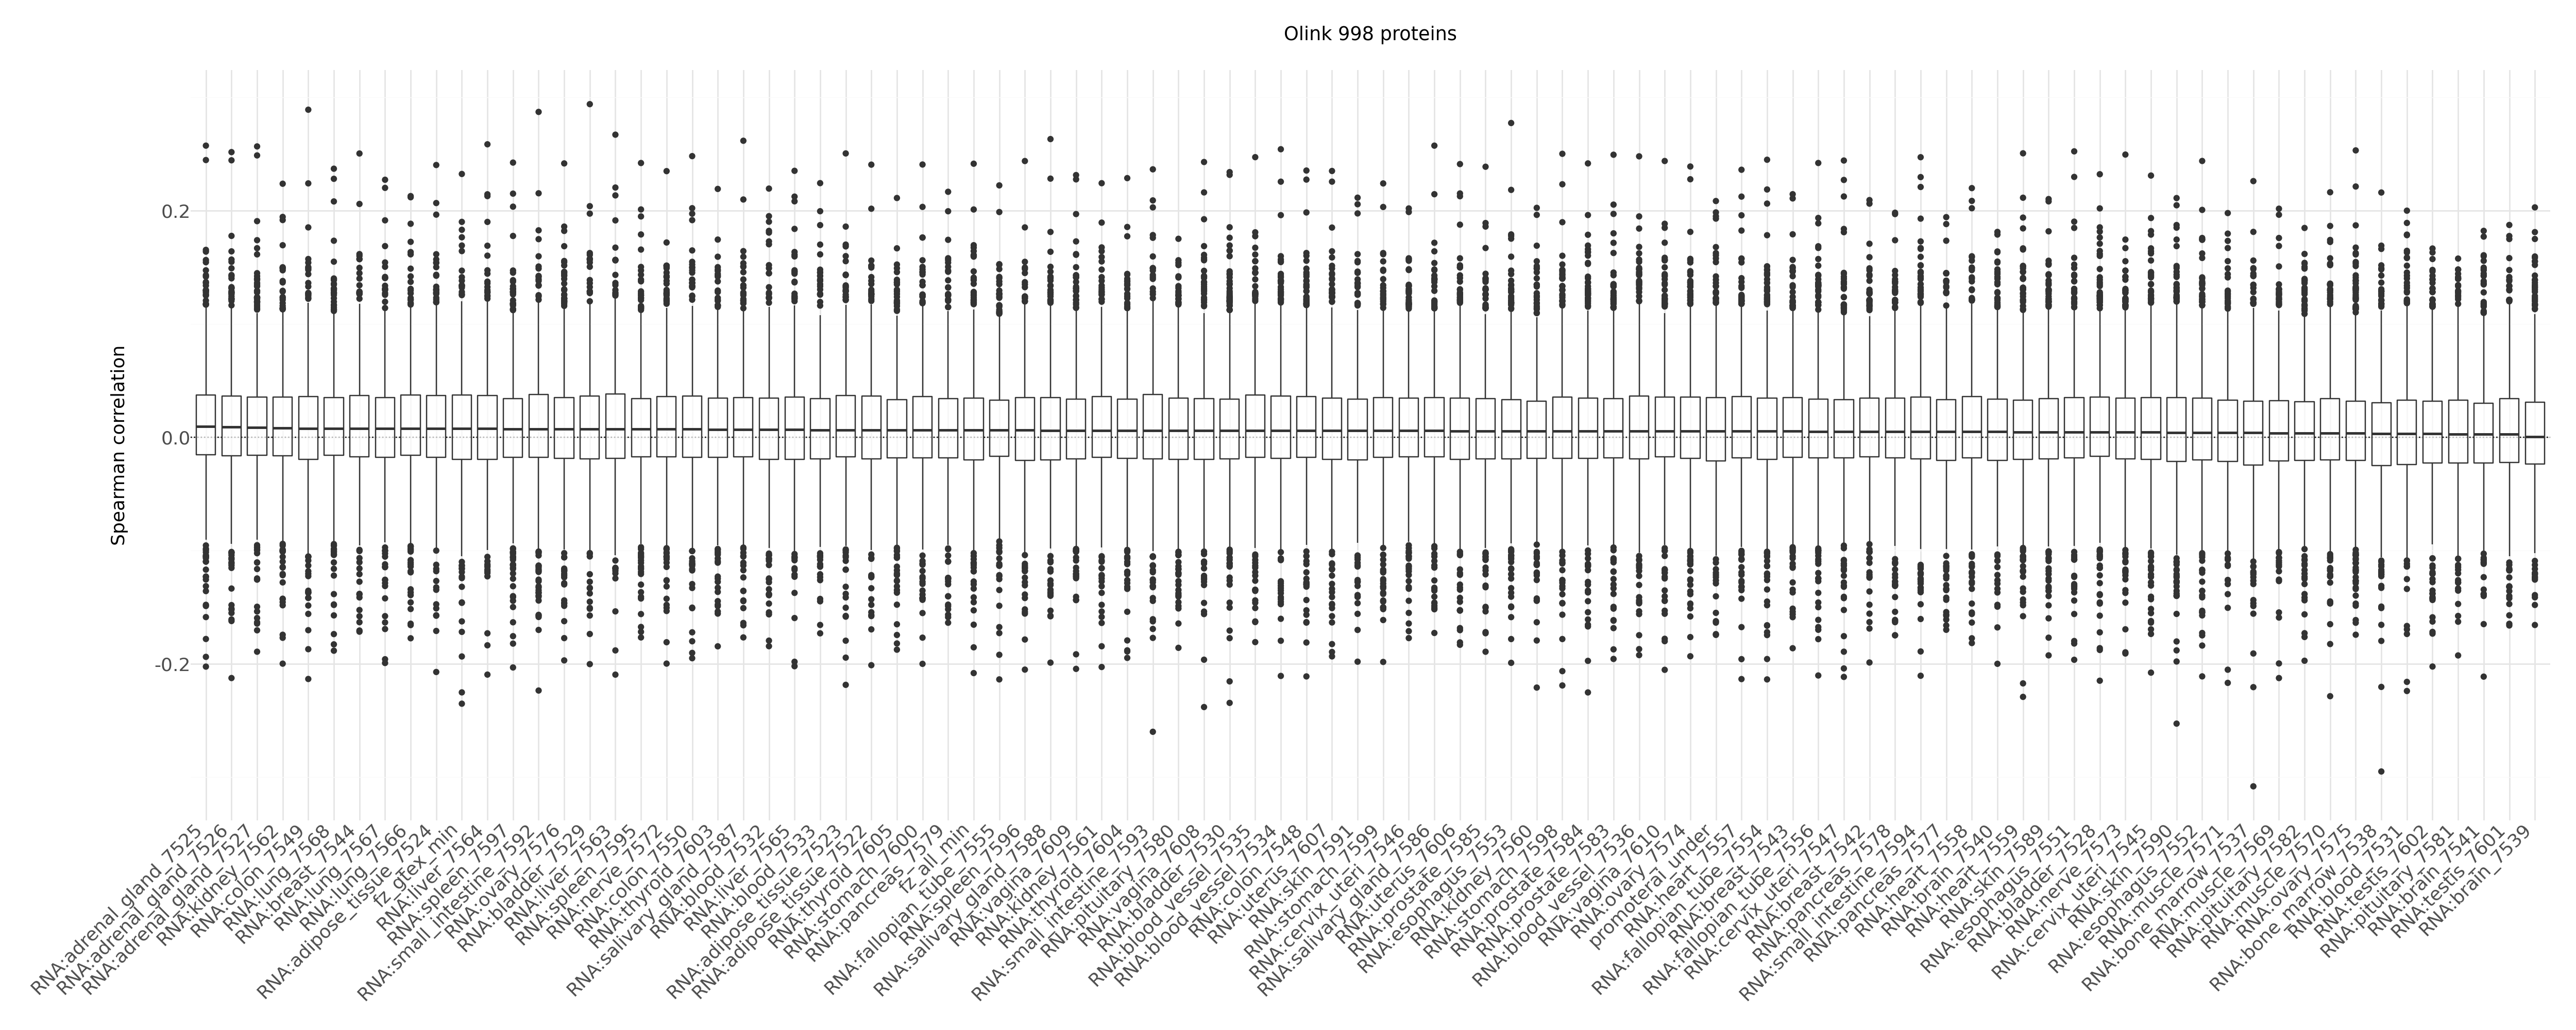

In [11]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=True)
    .select("annotation")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("annotation").cast(pl.Enum(ordered_labels)))

# Plot
(
    ggplot(corr_pl, aes(x="annotation", y=plotting_col))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7, outlier_shape=None)
    + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pl['region'].unique())} proteins"
    )
    + theme(
        figure_size=(25, 10),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

---
# Identify best tissue-per-gene based on correlation in train split

In [8]:
# Per-gene 50/50 split: for each (id, region) pair independently assign to train/test
# This ensures every gene has both train and test variants
rng_split = np.random.default_rng(42)

id_region_all = anno.select(['id', 'region']).unique()
n_pairs = len(id_region_all)

train_test_split = (
    id_region_all
    .with_columns(
        is_train=pl.Series(rng_split.random(n_pairs) < 0.5)
    )
)

train_id_region_df = train_test_split.filter(pl.col('is_train')).select(['id', 'region'])
test_id_region_df = train_test_split.filter(~pl.col('is_train')).select(['id', 'region'])

print(f"Total (id, region) pairs: {n_pairs:,}")
print(f"Train pairs: {train_id_region_df.shape[0]:,}")
print(f"Test pairs: {test_id_region_df.shape[0]:,}")

Total (id, region) pairs: 3,894,996
Train pairs: 1,949,019
Test pairs: 1,945,977


In [9]:
# Filter melted_anno to train (id, region) pairs and GTEx tissues only
train_melted_gtex = (
    melted_anno
    .join(train_id_region_df, on=['id', 'region'], how='semi')
    .filter(pl.col('annotation').is_in(gtex_cols))
)

# Spearman correlation per (gene, tissue) on train variants
train_corr_df = (
    olink_appv
    .join(train_id_region_df.lazy(), on='id', how='inner')
    .join(olink_whitelist[["region", "phenotype"]].lazy(), on=["region", "phenotype"], how="inner")
    .join(train_melted_gtex.lazy(), on=["id", "region"], how="inner")
    .with_columns(
        pl.col(c).rank("max").over(["region", "phenotype", "annotation"]).alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants=pl.col("id").count(),
        correlation=pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) &
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        ).then(pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True))
        .otherwise(None)
    )
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'])
    .with_columns(corr_beta=pl.col('correlation') * pl.col('loftee_corr_dir') * (-1))
    .drop_nans().drop_nulls()
    .collect(engine='streaming')
)

# Per gene: pick tissue with highest corr_beta (min 50 train variants)
best_tissue_by_corr = (
    train_corr_df
    .filter(pl.col('n_variants') >= 50)
    .sort('corr_beta', descending=True)
    .unique(subset=['region'], keep='first', maintain_order=True)
    .select(['region', pl.col('annotation').alias('best_tissue_corr'), 'corr_beta'])
)
print(f"Genes with best tissue (corr criterion): {best_tissue_by_corr.shape[0]}")
best_tissue_by_corr.head(10)

Genes with best tissue (corr criterion): 1055


region,best_tissue_corr,corr_beta
str,str,f64
"""ENSG00000118298""","""RNA:colon_7550""",0.412319
"""ENSG00000205403""","""RNA:skin_7590""",0.352937
"""ENSG00000179958""","""RNA:breast_7544""",0.339724
"""ENSG00000166340""","""RNA:breast_7543""",0.329203
"""ENSG00000134389""","""RNA:testis_7602""",0.31976
"""ENSG00000113905""","""RNA:heart_7557""",0.315229
"""ENSG00000095970""","""RNA:adrenal_gland_7526""",0.313362
"""ENSG00000155368""","""RNA:muscle_7571""",0.312146
"""ENSG00000163154""","""RNA:bladder_7528""",0.305807


---
## Best tissue by avg z-score (train)

In [10]:
# Select best tissue per gene by highest mean z-score of top K train variants
# mean_pheno_value in olink_appv is already = -original (positive for under-expressed variants)
top_k_list = [1_000, 10_000]

# Train variant z-scores (semi-join so only train (id, region) pairs are included)
train_variant_zscores = (
    olink_appv
    .join(train_id_region_df.lazy(), on='id', how='inner')
    .join(olink_whitelist[["region", "phenotype"]].lazy(), on=["region", "phenotype"], how="inner")
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

# For each (gene, tissue): rank train variants ascending by tissue score
# (most negative fz score = most disruptive → rank 1)
train_tissue_with_z = (
    train_melted_gtex.lazy()
    .join(train_variant_zscores.lazy(), on=['id', 'region'], how='inner')
    .with_columns(
        tissue_rank=pl.col('annotation_score').rank('min', descending=False).over(['region', 'annotation'])
    )
    .collect(engine='streaming')
)

best_tissue_by_zscore = {}
for top_k in top_k_list:
    best_t = (
        train_tissue_with_z.lazy()
        .filter(pl.col('tissue_rank') <= top_k)
        .group_by(['region', 'annotation'])
        .agg(mean_zscore_topk=pl.col('mean_pheno_value').mean(), n_vars=pl.len())
        .sort('mean_zscore_topk', descending=True)
        .unique(subset=['region'], keep='first', maintain_order=True)
        .select(['region', pl.col('annotation').alias(f'best_tissue_zscore_k{top_k}'), 'mean_zscore_topk'])
        .collect()
    )
    best_tissue_by_zscore[top_k] = best_t
    print(f"Top-{top_k:,}: {best_t.shape[0]} genes with best tissue")
    print(best_t.head(3))

Top-1,000: 1074 genes with best tissue
shape: (3, 3)
┌─────────────────┬──────────────────────────┬──────────────────┐
│ region          ┆ best_tissue_zscore_k1000 ┆ mean_zscore_topk │
│ ---             ┆ ---                      ┆ ---              │
│ str             ┆ str                      ┆ f32              │
╞═════════════════╪══════════════════════════╪══════════════════╡
│ ENSG00000205186 ┆ RNA:ovary_7576           ┆ 0.428084         │
│ ENSG00000169413 ┆ RNA:bone_marrow_7537     ┆ 0.366707         │
│ ENSG00000181143 ┆ RNA:small_intestine_7593 ┆ 0.312354         │
└─────────────────┴──────────────────────────┴──────────────────┘
Top-10,000: 1074 genes with best tissue
shape: (3, 3)
┌─────────────────┬───────────────────────────┬──────────────────┐
│ region          ┆ best_tissue_zscore_k10000 ┆ mean_zscore_topk │
│ ---             ┆ ---                       ┆ ---              │
│ str             ┆ str                       ┆ f32              │
╞═════════════════╪════════════

---
## Test set evaluation

In [12]:
# Filter melted_anno to test (id, region) pairs and GTEx tissues
test_melted_gtex = (
    melted_anno
    .join(test_id_region_df, on=['id', 'region'], how='semi')
    .filter(pl.col('annotation').is_in(gtex_cols))
)

# fz_best_tissue_corr: for each test (variant, gene), get the score of that gene's best tissue
test_scores_corr = (
    test_melted_gtex.lazy()
    .join(
        best_tissue_by_corr.lazy().rename({'best_tissue_corr': 'annotation'}),
        on=['region', 'annotation'],
        how='inner'
    )
    .select(['id', 'region', pl.col('annotation_score').alias('fz_best_tissue_corr')])
    .collect()
)

# fz_best_tissue_zscore_k1000 and fz_best_tissue_zscore_k10000
test_scores_zscore = {}
for top_k in top_k_list:
    col_name = f'fz_best_tissue_zscore_k{top_k}'
    test_scores_zscore[top_k] = (
        test_melted_gtex.lazy()
        .join(
            best_tissue_by_zscore[top_k].lazy().rename({f'best_tissue_zscore_k{top_k}': 'annotation'}),
            on=['region', 'annotation'],
            how='inner'
        )
        .select(['id', 'region', pl.col('annotation_score').alias(col_name)])
        .collect()
    )

# Baseline scores: promoterai_under, fz_all_min, fz_gtex_min from melted_anno (test pairs)
available_annos = melted_anno['annotation'].unique().to_list()
baseline_cols = [c for c in ['fz_all_min', 'fz_gtex_min', 'promoterai_under'] if c in available_annos]
test_baseline = (
    melted_anno
    .join(test_id_region_df, on=['id', 'region'], how='semi')
    .filter(pl.col('annotation').is_in(baseline_cols))
    .pivot(index=['id', 'region'], on='annotation', values='annotation_score', aggregate_function='first')
)

# Combine all test scores into one comparison table
test_comparison = test_scores_corr.lazy()
for top_k in top_k_list:
    test_comparison = test_comparison.join(test_scores_zscore[top_k].lazy(), on=['id', 'region'], how='outer_coalesce')
test_comparison = test_comparison.join(test_baseline.lazy(), on=['id', 'region'], how='outer_coalesce').collect()

print(f"Test comparison table: {test_comparison.shape}")
print(f"Columns: {test_comparison.columns}")
test_comparison.head()

/tmp/ipykernel_242915/1617669937.py:48: DeprecationWarning: use of `how='outer_coalesce'` should be replaced with `how='full', coalesce=True`.
(Deprecated in version 0.20.29)
/tmp/ipykernel_242915/1617669937.py:49: DeprecationWarning: use of `how='outer_coalesce'` should be replaced with `how='full', coalesce=True`.
(Deprecated in version 0.20.29)


Test comparison table: (2357949, 8)
Columns: ['id', 'region', 'fz_best_tissue_corr', 'fz_best_tissue_zscore_k1000', 'fz_best_tissue_zscore_k10000', 'promoterai_under', 'fz_all_min', 'fz_gtex_min']


id,region,fz_best_tissue_corr,fz_best_tissue_zscore_k1000,fz_best_tissue_zscore_k10000,promoterai_under,fz_all_min,fz_gtex_min
str,str,f32,f32,f32,f32,f32,f32
"""chr3:51976015:C:T""","""ENSG00000114779""",-0.078008,-0.057869,-0.057869,0.0,-0.097288,-0.080088
"""chr17:39698250:T:G""","""ENSG00000141736""",-0.000509,-0.000573,-0.000573,0.0,-0.002817,-0.002817
"""chr17:39716278:C:T""","""ENSG00000141736""",0.002086,0.002541,0.002541,-0.0432,-0.014006,-0.01048
"""chr8:119603367:A:G""","""ENSG00000136960""",-0.004315,-0.005706,-0.005706,0.0,-0.070592,-0.070592
"""chr12:7125961:A:G""","""ENSG00000139182""",-0.003811,-0.000171,-0.000171,0.0,-0.003811,-0.003811


In [13]:
# Comparison annotations to evaluate on the test set
comp_cols = [
    'fz_best_tissue_corr',
    'fz_best_tissue_zscore_k1000',
    'fz_best_tissue_zscore_k10000',
    'fz_all_min',
    'fz_gtex_min',
    'promoterai_under',
]
comp_cols = [c for c in comp_cols if c in test_comparison.columns]

# Test variant z-scores (mean_pheno_value = -original, positive for under-expressed variants)
test_variant_zscores = (
    olink_appv
    .join(test_id_region_df.lazy(), on='id', how='inner')
    .join(olink_whitelist[["region", "phenotype", "loftee_corr_dir"]].lazy(), on=['region', 'phenotype'], how='inner')
    .select(['id', 'region', 'phenotype', 'mean_pheno_value', 'loftee_corr_dir'])
    .collect(engine='streaming')
)

# Compute Spearman corr per (gene, annotation) on test
all_test_corrs = []
for col in comp_cols:
    corr_df = (
        test_variant_zscores.lazy()
        .join(test_comparison.lazy().select(['id', 'region', col]).drop_nulls(), on=['id', 'region'], how='inner')
        .with_columns(
            anno_rank=pl.col(col).rank("average").over(["region", "phenotype"]),
            pheno_rank=pl.col('mean_pheno_value').rank("average").over(["region", "phenotype"]),
        )
        .group_by(["region", "phenotype"])
        .agg(
            n_variants=pl.col('id').count(),
            correlation=pl.corr("anno_rank", "pheno_rank", propagate_nans=True)
        )
        .join(olink_whitelist.lazy(), on=['region', 'phenotype'])
        .with_columns(
            corr_beta=pl.col('correlation') * pl.col('loftee_corr_dir') * (-1),
            annotation=pl.lit(col)
        )
        .collect()
    )
    all_test_corrs.append(corr_df)

test_corr_results = pl.concat(all_test_corrs)

# Summary table
test_corr_summary = (
    test_corr_results
    .group_by('annotation')
    .agg(
        n_genes=pl.len(),
        mean_corr_beta=pl.col('corr_beta').mean(),
        median_corr_beta=pl.col('corr_beta').median(),
        se_corr_beta=pl.col('corr_beta').std() / pl.col('corr_beta').len().sqrt(),
    )
    .sort('mean_corr_beta', descending=True)
)
test_corr_summary

annotation,n_genes,mean_corr_beta,median_corr_beta,se_corr_beta
str,u64,f64,f64,f64
"""promoterai_under""",1074,NaN,0.009162,NaN
"""fz_gtex_min""",1074,0.010572,0.009928,0.00245
"""fz_best_tissue_zscore_k1000""",1074,0.008732,0.007997,0.002351
"""fz_best_tissue_zscore_k10000""",1074,0.008605,0.007349,0.00239
"""fz_all_min""",1074,0.0076,0.007036,0.002474
"""fz_best_tissue_corr""",1055,0.00619,0.005823,0.002307


In [21]:
test_corr_results

region,phenotype,n_variants,correlation,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,annotation
str,str,u64,f64,f64,f64,f64,f64,str
"""ENSG00000116675""","""ENSG00000116675_olink""",1112,0.021861,0.022487,0.022487,1.0,-0.021861,"""fz_best_tissue_corr"""
"""ENSG00000123609""","""ENSG00000123609_olink""",134,-0.089527,0.076186,0.076186,1.0,0.089527,"""fz_best_tissue_corr"""
"""ENSG00000167851""","""ENSG00000167851_olink""",224,0.047146,0.066067,0.066067,1.0,-0.047146,"""fz_best_tissue_corr"""
"""ENSG00000156711""","""ENSG00000156711_olink""",227,-0.008309,0.04852,0.04852,1.0,0.008309,"""fz_best_tissue_corr"""
"""ENSG00000174990""","""ENSG00000174990_olink""",727,-0.02265,0.010786,0.010786,1.0,0.02265,"""fz_best_tissue_corr"""
…,…,…,…,…,…,…,…,…
"""ENSG00000136542""","""ENSG00000136542_olink""",343,0.004701,0.040315,0.040315,1.0,-0.004701,"""promoterai_under"""
"""ENSG00000196576""","""ENSG00000196576_olink""",722,0.007691,0.082542,0.082542,1.0,-0.007691,"""promoterai_under"""
"""ENSG00000111144""","""ENSG00000111144_olink""",466,0.031764,0.088107,0.088107,1.0,-0.031764,"""promoterai_under"""


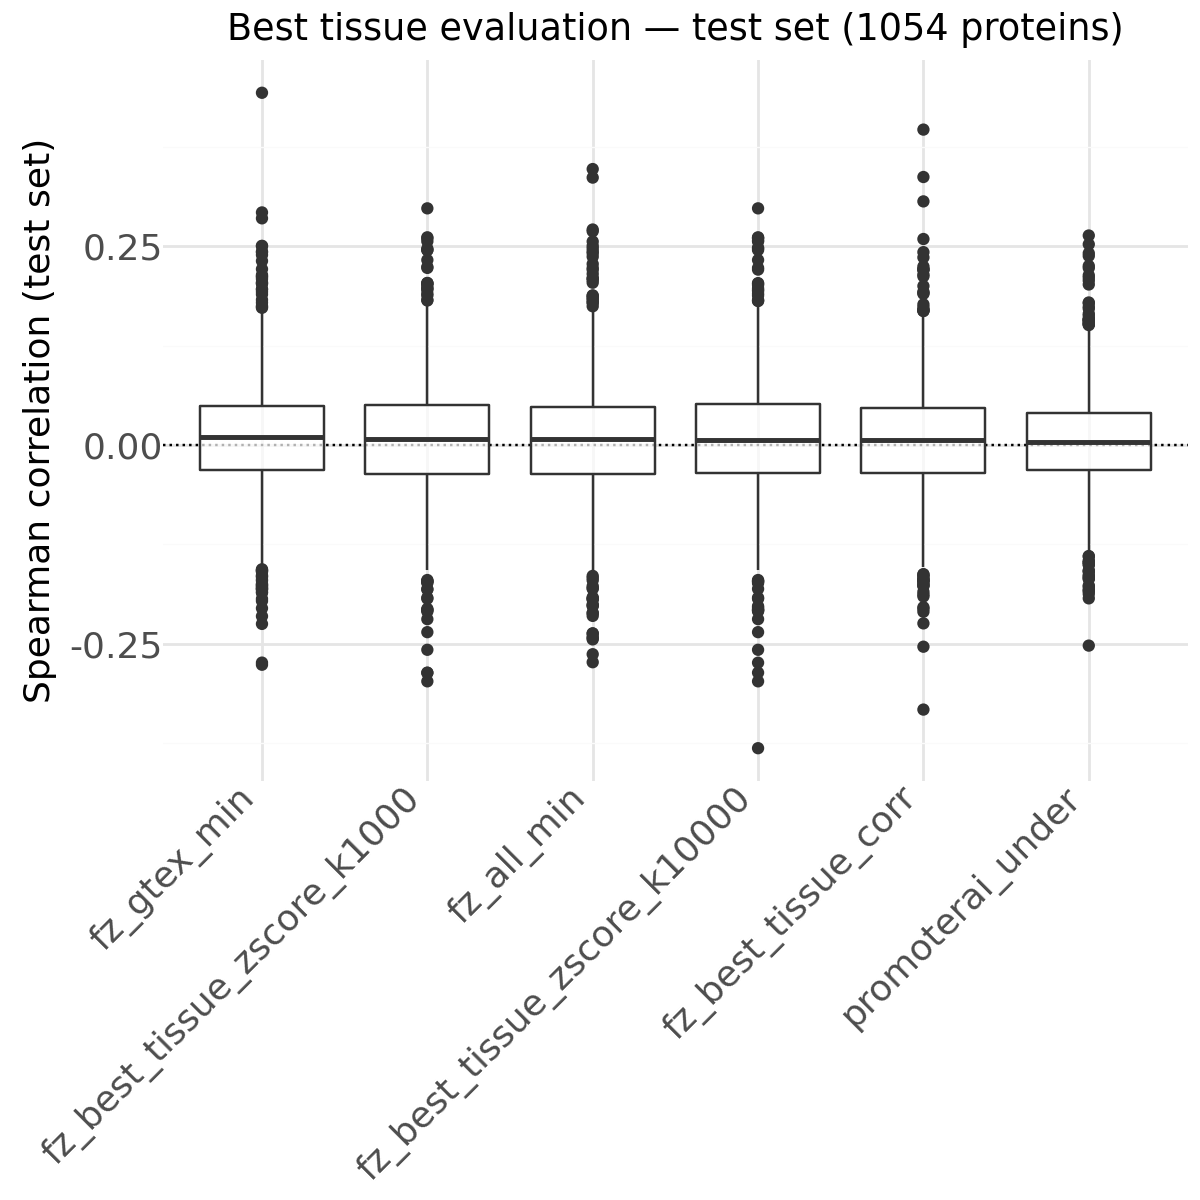

In [15]:
# Boxplot of corr_beta on the test set, one box per annotation
corr_test_pl = (
    test_corr_results
    .drop_nans()
    .filter(pl.col('n_variants') > 50)
    .with_columns(median_corr_beta=pl.col('corr_beta').median().over("annotation"))
)
ordered_test_labels = (
    corr_test_pl
    .sort("median_corr_beta", descending=True)
    .select("annotation")
    .unique(maintain_order=True)
    .to_series()
)
corr_test_pl = corr_test_pl.with_columns(pl.col("annotation").cast(pl.Enum(ordered_test_labels)))

(
    ggplot(corr_test_pl, aes(x="annotation", y="corr_beta"))
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + labs(
        x="",
        y="Spearman correlation (test set)",
        title=f"Best tissue evaluation — test set ({len(corr_test_pl['region'].unique())} proteins)",
    )
    + theme(
        figure_size=(6, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        plot_background=element_rect(fill="white", color="white"),
    )
)

---
## Avg z-score of top N variants — sliding window + bootstrap (test set)

In [16]:
# Parameters (match those in olink_avg_zscore_gene_bootstrap.ipynb)
window_size_test = 1_000
step_size_test = 10
n_boot_test = 1_000
target_k_test = np.array([1_000, 10_000], dtype=np.int64)
ci_factor_test = 1  # ±1 SE bands

# All fz_* annotations use annotation_dir = -1 (lower score = more disruptive)
# Melt test_comparison into long format
test_melted_comp = (
    test_comparison.lazy()
    .unpivot(index=['id', 'region'], on=comp_cols, variable_name='annotation', value_name='annotation_score')
    .drop_nulls('annotation_score')
    .collect()
)

# Gene index map for bootstrap resampling
all_regions_test = sorted(olink_whitelist['region'].unique().to_list())
n_regions_test = len(all_regions_test)
region_idx_map_test = pl.DataFrame({
    'region': all_regions_test,
    '_region_idx': np.arange(n_regions_test, dtype=np.int32)
})

# Build ranked z-score table: annotation_dir = -1 → negate score before descending rank
ranked_test_zscores = (
    test_melted_comp.lazy()
    .join(test_variant_zscores.lazy().select(['id', 'region', 'mean_pheno_value']), on=['id', 'region'], how='inner')
    .with_columns(annotation_score_dircor=pl.col('annotation_score') * (-1))  # annotation_dir = -1
    .with_columns(
        annotation_score_dircor_rank_desc=(
            pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
        )
    )
    .sort(['annotation', 'annotation_score_dircor_rank_desc'])
    .with_columns(row_pos=pl.col('annotation').cum_count().over('annotation'))
    .collect(engine='streaming')
    .join(region_idx_map_test, on='region', how='left')
)

annotations_list_test = sorted(ranked_test_zscores['annotation'].unique().to_list())
print(f"Annotations: {annotations_list_test}")
print(f"Ranked test z-score table: {ranked_test_zscores.shape}")

Annotations: ['fz_all_min', 'fz_best_tissue_corr', 'fz_best_tissue_zscore_k1000', 'fz_best_tissue_zscore_k10000', 'fz_gtex_min', 'promoterai_under']
Ranked test z-score table: (3114283, 9)


In [17]:
# --- Helper functions (same as olink_avg_zscore_gene_bootstrap.ipynb) ---

def sliding_window_means_unweighted(zscores, bin_ends, window_size):
    """Standard prefix-sum sliding window mean (for point estimates)."""
    csum = np.empty(len(zscores) + 1, dtype=np.float64)
    csum[0] = 0.0
    np.cumsum(zscores, out=csum[1:])
    return (csum[bin_ends] - csum[bin_ends - window_size]) / window_size


def expanded_csum_at(positions, cw, cwz, z, N):
    k = np.searchsorted(cw, positions, side='left')
    k_safe = np.clip(k, 1, N)
    result = cwz[k_safe - 1] + z[k_safe - 1] * (positions - cw[k_safe - 1])
    result = np.where(positions <= 0, 0.0, result)
    return result


def sliding_window_reranked(z, cw, cwz, N, total_expanded, bin_ends, window_size):
    valid_mask = bin_ends <= total_expanded
    valid_bins = bin_ends[valid_mask]
    means = np.full(len(bin_ends), np.nan, dtype=np.float64)
    if len(valid_bins) == 0:
        return means
    right = expanded_csum_at(valid_bins, cw, cwz, z, N)
    left = expanded_csum_at(valid_bins - window_size, cw, cwz, z, N)
    means[valid_mask] = (right - left) / window_size
    return means


# --- Prepare per-annotation arrays ---
anno_arrays_test = {}
for annotation in tqdm(annotations_list_test, desc='Preparing arrays'):
    adf = ranked_test_zscores.filter(pl.col('annotation') == annotation)
    z = adf['mean_pheno_value'].to_numpy().astype(np.float64)
    r_idx = adf['_region_idx'].to_numpy()
    N = len(z)
    bin_ends = np.arange(window_size_test, N + 1, step_size_test, dtype=np.int64)
    anno_arrays_test[annotation] = {'zscores': z, 'region_idx': r_idx, 'bin_ends': bin_ends, 'N': N}

# Filter target_k to available variant counts
min_variants_test = min(d['N'] for d in anno_arrays_test.values())
target_k_test = target_k_test[target_k_test <= min_variants_test]
print(f"Heatmap thresholds: {target_k_test} (min variants: {min_variants_test})")

# --- Point estimates ---
point_means_test = {
    ann: sliding_window_means_unweighted(anno_arrays_test[ann]['zscores'], anno_arrays_test[ann]['bin_ends'], window_size_test)
    for ann in annotations_list_test
}

# --- Re-ranking bootstrap CIs across genes ---
rng_test = np.random.default_rng(42)
boot_means_test = {ann: np.full((n_boot_test, len(anno_arrays_test[ann]['bin_ends'])), np.nan) for ann in annotations_list_test}
boot_discrete_test = {ann: np.full((n_boot_test, len(target_k_test)), np.nan) for ann in annotations_list_test}

max_N_test = max(d['N'] for d in anno_arrays_test.values())
cw_buf = np.empty(max_N_test + 1, dtype=np.float64)
cwz_buf = np.empty(max_N_test + 1, dtype=np.float64)

for b in tqdm(range(n_boot_test), desc='Bootstrap (test set)'):
    idx = rng_test.choice(n_regions_test, size=n_regions_test, replace=True)
    region_weights = np.bincount(idx, minlength=n_regions_test).astype(np.float64)

    for annotation in annotations_list_test:
        d = anno_arrays_test[annotation]
        N = d['N']
        z = d['zscores']
        vw = region_weights[d['region_idx']]

        cw = cw_buf[:N + 1]
        cw[0] = 0.0
        np.cumsum(vw, out=cw[1:])

        cwz = cwz_buf[:N + 1]
        cwz[0] = 0.0
        np.cumsum(z * vw, out=cwz[1:])

        total_expanded = int(cw[N])

        boot_means_test[annotation][b] = sliding_window_reranked(
            z, cw, cwz, N, total_expanded, d['bin_ends'], window_size_test
        )

        csums = expanded_csum_at(target_k_test, cw, cwz, z, N)
        boot_discrete_test[annotation][b] = csums / target_k_test

# --- Build output DataFrame ---
all_results_test = []
for annotation in tqdm(annotations_list_test):
    d = anno_arrays_test[annotation]
    bm = boot_means_test[annotation]
    boot_mean = np.nanmean(bm, axis=0)
    boot_se = np.nanstd(bm, axis=0).astype(np.float32)
    all_results_test.append(pl.DataFrame({
        'annotation': annotation,
        'bin_end': d['bin_ends'].astype(np.float64),
        'mean_zscore': boot_mean,
        'se_zscore': boot_se,
        'ci_lower': (boot_mean - ci_factor_test * boot_se).astype(np.float32),
        'ci_upper': (boot_mean + ci_factor_test * boot_se).astype(np.float32),
    }))

zscore_binned_test = pl.concat(all_results_test).sort(['annotation', 'bin_end'])
print(f"Sliding window results: {zscore_binned_test.shape[0]} points across {zscore_binned_test['annotation'].n_unique()} annotations")
zscore_binned_test

Preparing arrays: 100%|██████████| 6/6 [00:00<00:00, 33.15it/s]


Heatmap thresholds: [ 1000 10000] (min variants: 518483)


100%|██████████| 6/6 [00:05<00:00,  1.18it/s]

Sliding window results: 310834 points across 6 annotations


annotation,bin_end,mean_zscore,se_zscore,ci_lower,ci_upper
str,f64,f64,f32,f32,f32
"""fz_all_min""",1000.0,0.232266,0.059713,0.172553,0.291978
"""fz_all_min""",1010.0,0.222264,0.059463,0.162801,0.281727
"""fz_all_min""",1020.0,0.216324,0.059096,0.157228,0.275419
"""fz_all_min""",1030.0,0.212773,0.059115,0.153658,0.271888
"""fz_all_min""",1040.0,0.2108,0.059153,0.151647,0.269954
…,…,…,…,…,…
"""promoterai_under""",519120.0,0.004553,0.074244,-0.069691,0.078798
"""promoterai_under""",519130.0,0.004054,0.073772,-0.069718,0.077826
"""promoterai_under""",519140.0,0.003987,0.073521,-0.069534,0.077508


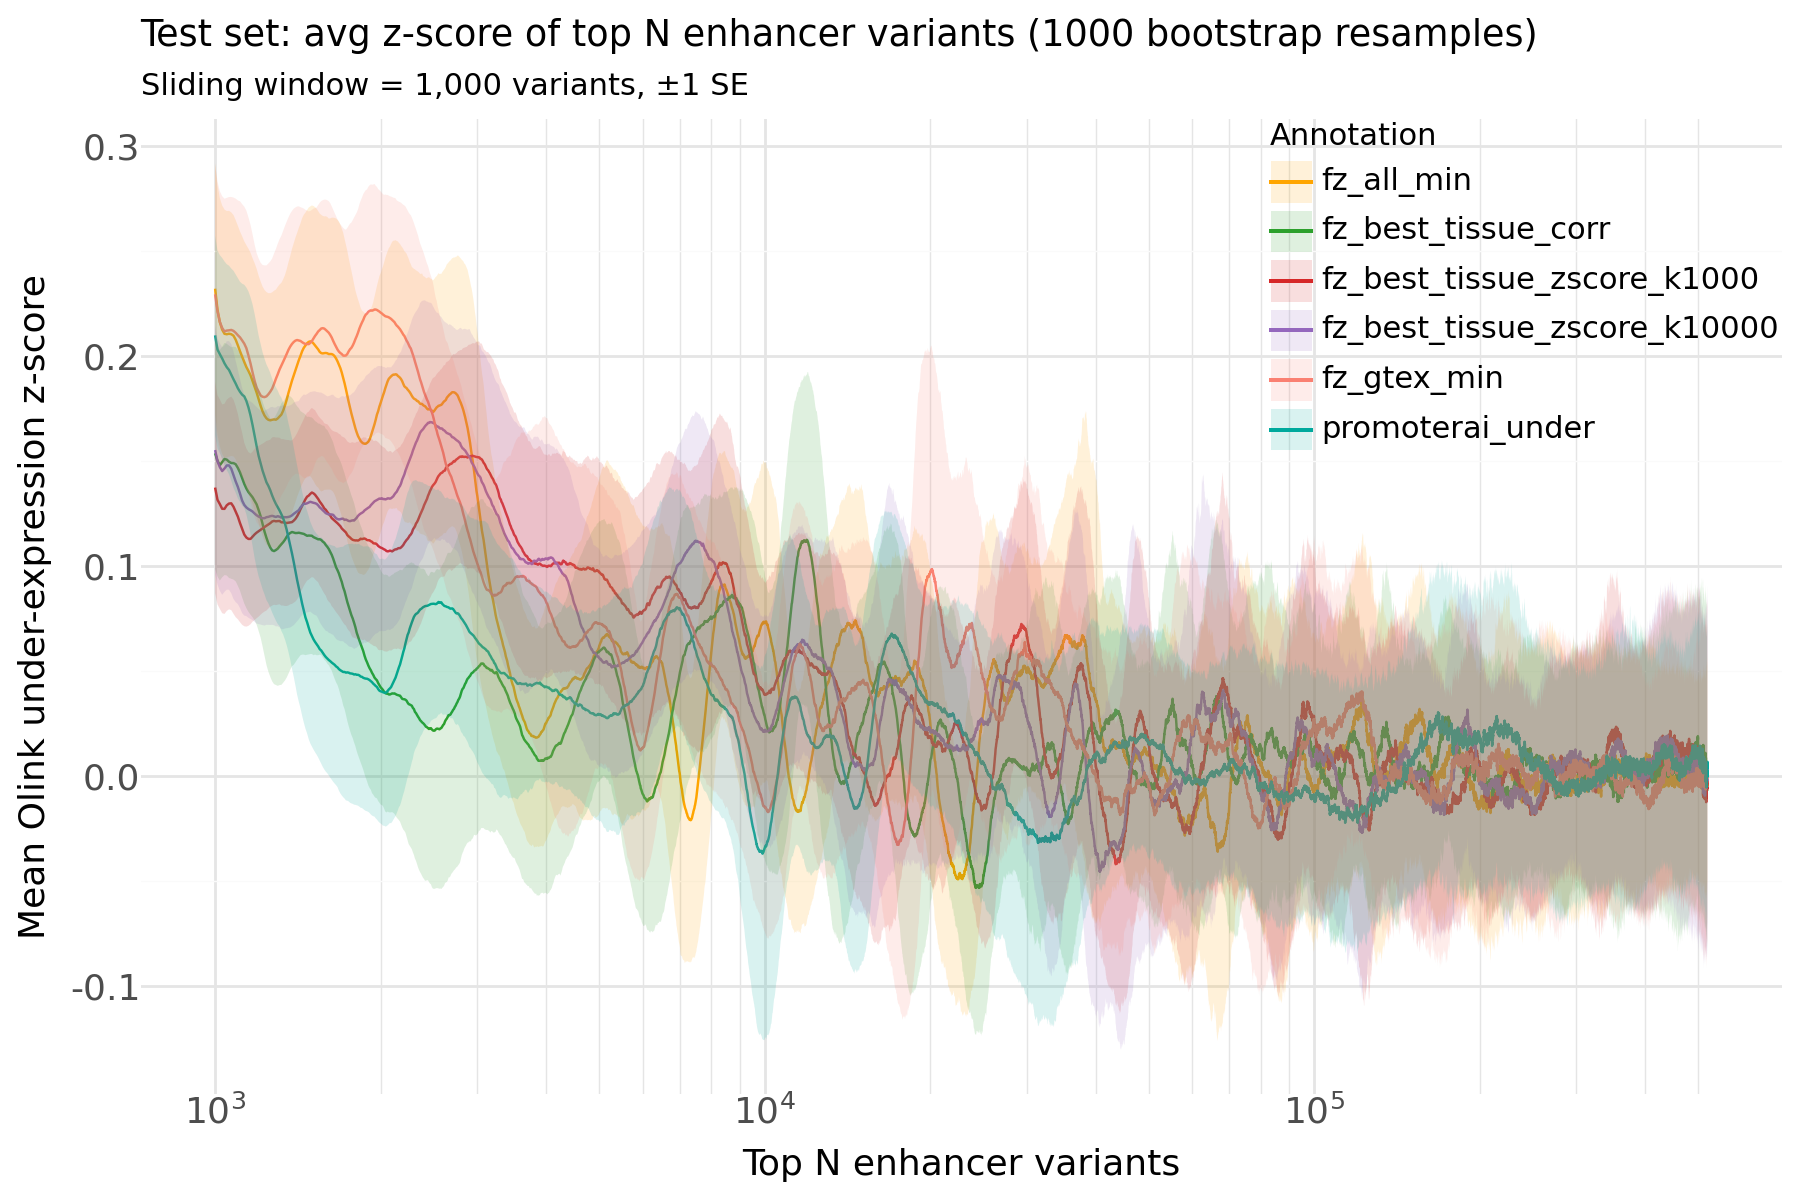

In [20]:
# Line plot: sliding window avg z-score on test set
# Assign colors: best-tissue annotations get distinct colors; baselines use their config colors
color_map_test = {
    'fz_best_tissue_corr':          '#2ca02c',   # green
    'fz_best_tissue_zscore_k1000':  '#d62728',   # red
    'fz_best_tissue_zscore_k10000': '#9467bd',   # purple
    'fz_all_min':                   '#FFA500',
    'fz_gtex_min':                  'salmon',
    'promoterai_under':             '#00A99D',
}

plt_df_test = (
    zscore_binned_test
    .drop_nans()
    .with_columns(log_bin_end=pl.col('bin_end').log10())
    .with_columns(color=pl.col('annotation').replace(color_map_test))
)

max_rank_t = zscore_binned_test['bin_end'].max()
min_rank_t = zscore_binned_test['bin_end'].min()
start_exp_t = int(np.floor(np.log10(min_rank_t)))
end_exp_t = int(np.ceil(np.log10(max_rank_t)))
breaks_t = np.arange(start_exp_t, end_exp_t + 1)
labels_t = [f"$10^{{{int(b)}}}$" for b in breaks_t]
minor_breaks_t = [b for k in range(start_exp_t, end_exp_t) for b in [k + np.log10(m) for m in range(2, 10)] if min_rank_t <= 10**b <= max_rank_t]

color_dict_test = dict(zip(plt_df_test['annotation'], plt_df_test['color']))

(
    ggplot(plt_df_test, aes(x='log_bin_end', y='mean_zscore'))
    + geom_line(aes(color='annotation'))
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='annotation'), alpha=0.15)
    + scale_color_manual(values=color_dict_test)
    + scale_fill_manual(values=color_dict_test)
    + scale_x_continuous(breaks=breaks_t, labels=labels_t, minor_breaks=minor_breaks_t)
    + labs(
        title=f"Test set: avg z-score of top N enhancer variants ({n_boot_test} bootstrap resamples)",
        subtitle=f"Sliding window = {window_size_test:,} variants, ±{ci_factor_test} SE",
        y="Mean Olink under-expression z-score",
        x="Top N enhancer variants",
        color="Annotation",
        fill="Annotation",
    )
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        legend_position=(1, 1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        panel_grid_minor_x=element_line(color="#e5e5e5", size=0.5),
        legend_text=element_text(size=11),
        legend_title=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

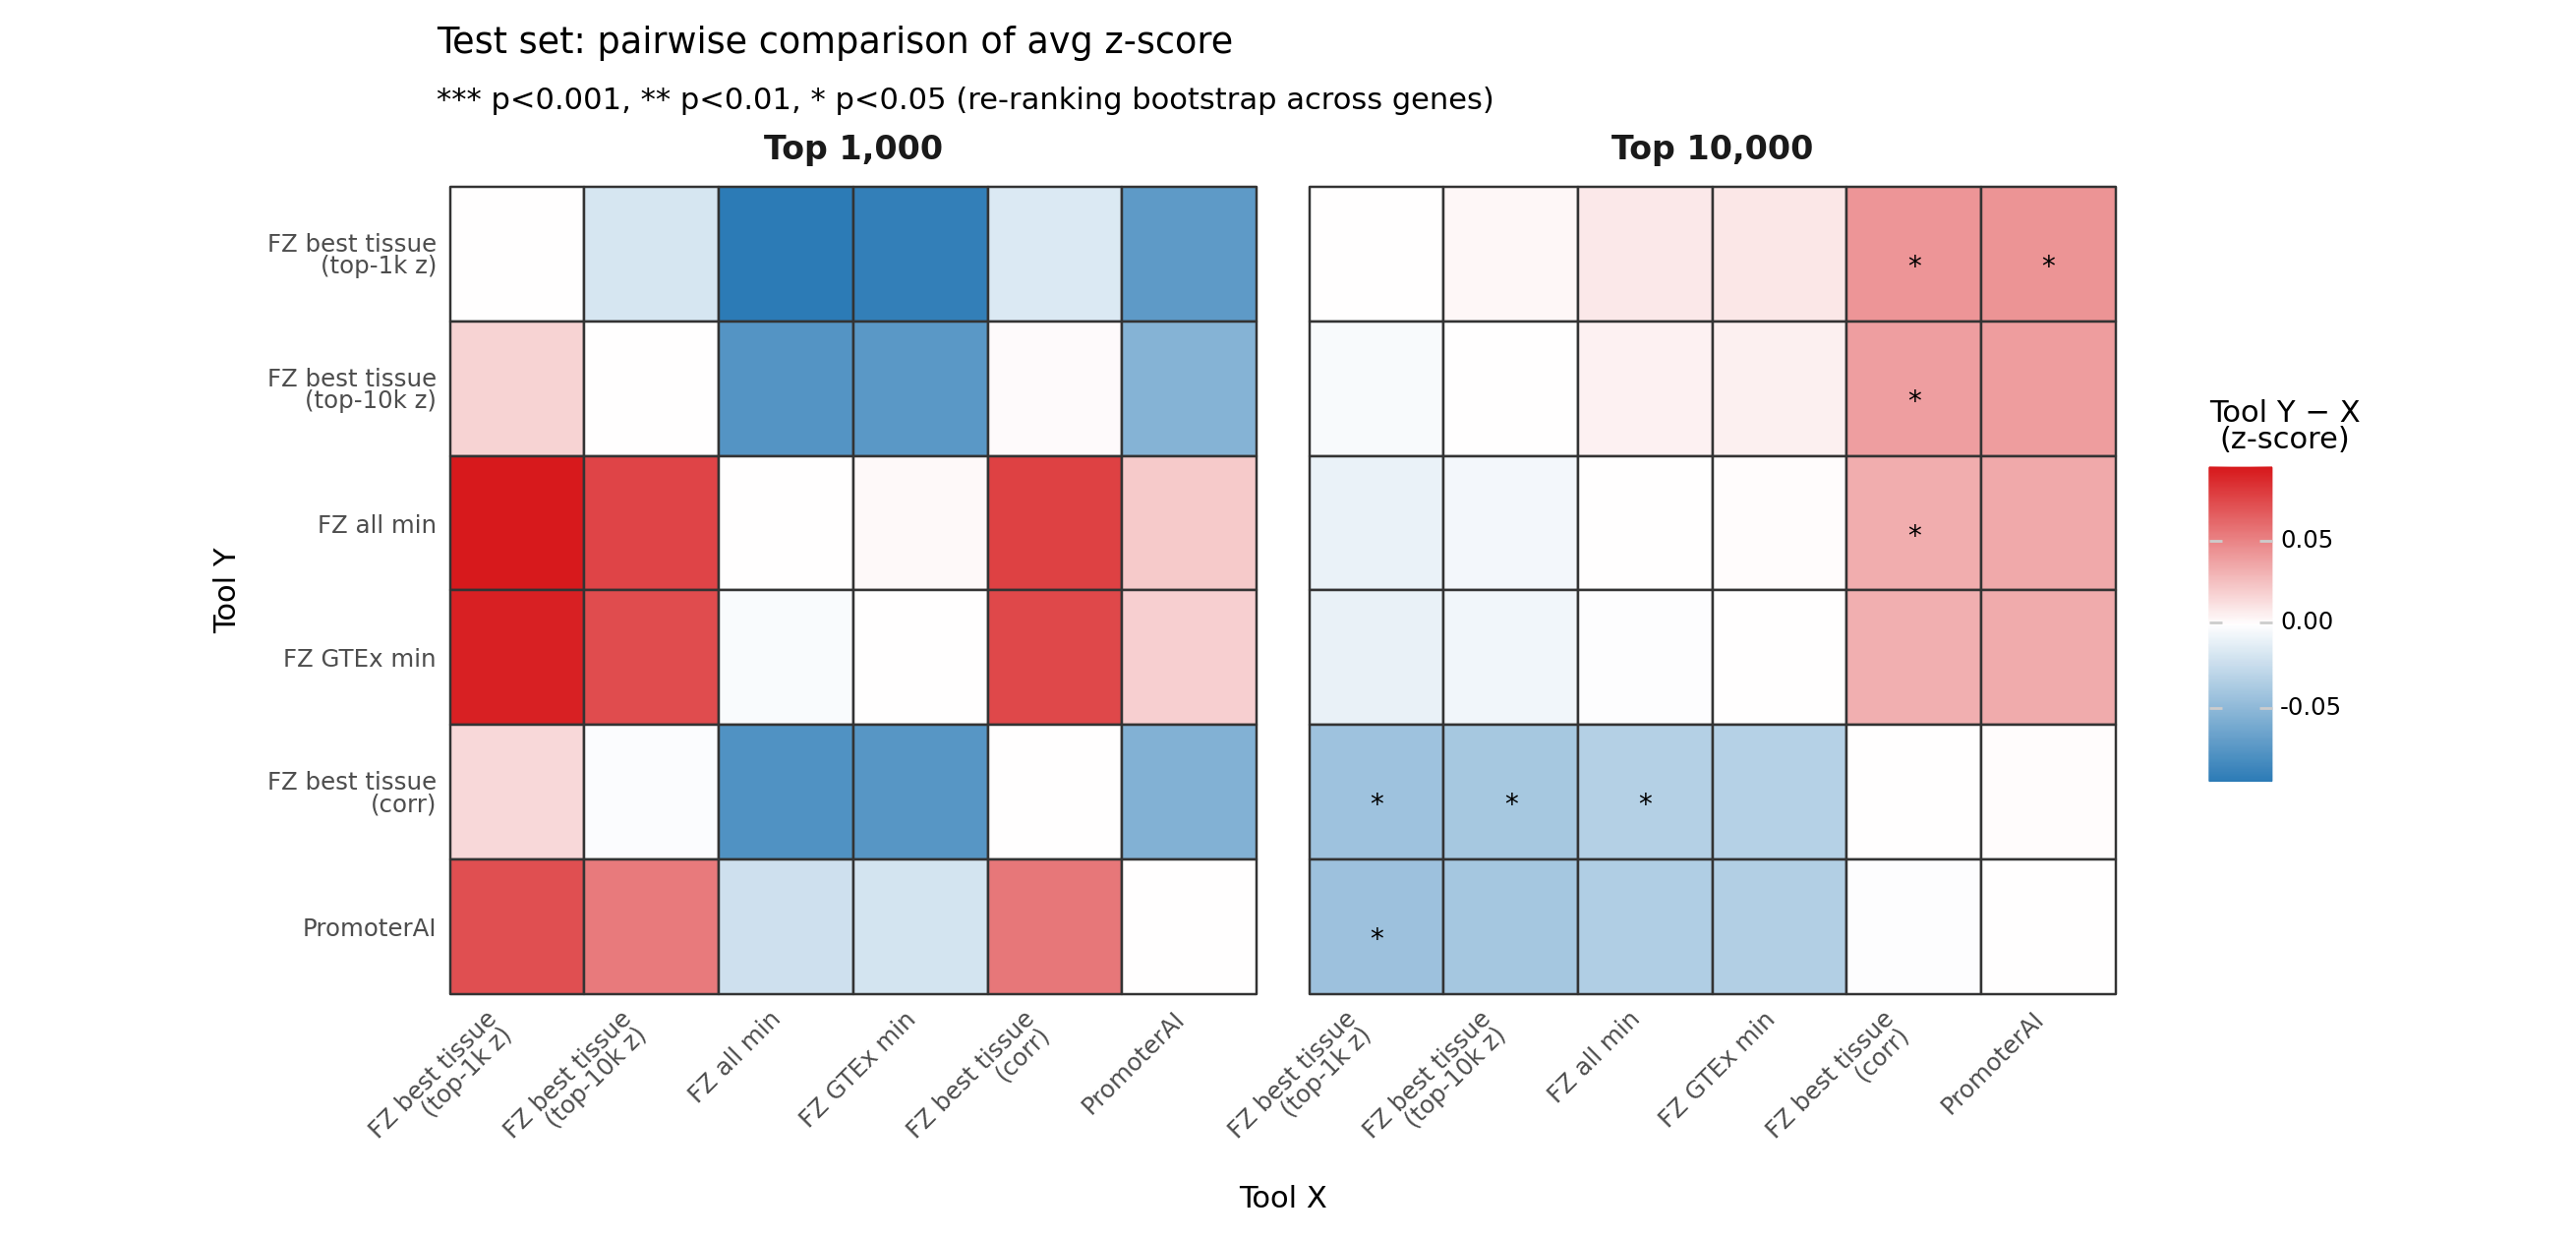

In [19]:
import pandas as pd
import itertools

# Heatmap of pairwise bootstrap significance on test set
# Global label map for display
label_map_test = {
    'fz_best_tissue_corr':          'FZ best tissue\n(corr)',
    'fz_best_tissue_zscore_k1000':  'FZ best tissue\n(top-1k z)',
    'fz_best_tissue_zscore_k10000': 'FZ best tissue\n(top-10k z)',
    'fz_all_min':                   'FZ all min',
    'fz_gtex_min':                  'FZ GTEx min',
    'promoterai_under':             'PromoterAI',
}

# Rank tools by mean z-score at top-10k (or last available target_k)
rank_idx_t = min(1, len(target_k_test) - 1)
tool_means_t = {ann: np.nanmean(boot_discrete_test[ann][:, rank_idx_t]) for ann in annotations_list_test}
ordered_tools_t = sorted(tool_means_t.keys(), key=lambda x: tool_means_t[x], reverse=True)
ordered_labels_t = [label_map_test.get(t, t) for t in ordered_tools_t]

heatmap_data_t = []
for i, k_val in enumerate(target_k_test):
    for ann_x, ann_y in itertools.product(ordered_tools_t, repeat=2):
        label_x = label_map_test.get(ann_x, ann_x)
        label_y = label_map_test.get(ann_y, ann_y)
        if ann_x == ann_y:
            heatmap_data_t.append({'Window': f"Top {k_val:,}", 'Window_Int': k_val,
                                   'Tool_X': label_x, 'Tool_Y': label_y, 'mean_diff': 0.0, 'sig': ''})
            continue
        boot_x = boot_discrete_test[ann_x][:, i]
        boot_y = boot_discrete_test[ann_y][:, i]
        diff = boot_y - boot_x
        mean_diff = np.nanmean(diff)
        p_val = 2 * min(np.nanmean(diff <= 0), np.nanmean(diff >= 0))
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
        heatmap_data_t.append({'Window': f"Top {k_val:,}", 'Window_Int': k_val,
                                'Tool_X': label_x, 'Tool_Y': label_y, 'mean_diff': mean_diff, 'sig': sig})

df_heat_t = pd.DataFrame(heatmap_data_t).sort_values('Window_Int')
df_heat_t['Window'] = pd.Categorical(df_heat_t['Window'], categories=df_heat_t['Window'].unique(), ordered=True)
df_heat_t['Tool_X'] = pd.Categorical(df_heat_t['Tool_X'], categories=ordered_labels_t, ordered=True)
df_heat_t['Tool_Y'] = pd.Categorical(df_heat_t['Tool_Y'], categories=ordered_labels_t[::-1], ordered=True)

n_facets_t = len(target_k_test)
n_tools_t = len(ordered_tools_t)

(
    ggplot(df_heat_t, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=10, va='center', nudge_y=-0.1)
    + facet_wrap('~Window', ncol=n_facets_t)
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0)
    + labs(
        title="Test set: pairwise comparison of avg z-score",
        subtitle="*** p<0.001, ** p<0.01, * p<0.05 (re-ranking bootstrap across genes)",
        x="Tool X", y="Tool Y", fill="Tool Y − X\n(z-score)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_facets_t * (n_tools_t * 0.8 + 1.0) + 1.5, n_tools_t * 0.8 + 1.5),
        aspect_ratio=1,
        axis_text_x=element_text(rotation=45, hjust=1),
        strip_text=element_text(size=12, face='bold'),
        panel_grid=element_blank(),
        plot_background=element_rect(fill="white", color="white"),
    )
)